## Static Test Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

from collections import defaultdict

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"
PLOTTING_DPI = 75
static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
STATIC_VEH, MOVING_VEH = 1, 2
VEH_NAME_MAP = {1: "static", 2: "moving"}
test_preset_map = defaultdict(dict)
test_preset_map['PLOTTING_DPI'] = PLOTTING_DPI
test_preset_map['STATIC_VEH'] = STATIC_VEH
test_preset_map['MOVING_VEH'] = MOVING_VEH
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
#############################################
# if skip plotting any tests, list them here
skiptests = []
#############################################
all_test_files = get_test_files_and_survey("Static Test", "V2")[0]
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = None
static_tests = {}

## Parse and store the data for all the tests

In [2]:
for test in all_test_names:
    static_tests[test] = parse_single_test_data(test_raw_name_file_map[test]["B"],
                                                "Static Test",
                                                test_preset_map)

processing: 2021-05-25-08-47-11-static-v2-2
processing: 2021-05-25-08-52-15-static-v2-3
processing: 2021-05-25-08-55-36-static-v2-4
processing: 2021-05-25-09-08-13-static-v2-5
processing: 2021-05-25-09-12-21-static-v2-6
processing: 2021-05-25-09-16-22-static-v2-7
processing: 2021-05-25-09-20-18-static-v2-8
processing: 2021-05-25-09-23-50-static-v2-9
processing: 2021-05-25-09-27-41-static-v2-10
processing: 2021-05-25-09-31-46-static-v2-11
processing: 2021-05-25-09-35-42-static-v2-12
processing: 2021-05-25-09-39-16-static-v2-13
processing: 2021-05-25-09-42-52-static-v2-14


In [3]:
# Global Statistics
static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

# Combination of All, Indexed by Time
list_df_time_idx_static = []
list_df_time_idx_moving = []

# Combination of All, Indexed by Ground Truth Distances
list_df_dist_idx_static = []
list_df_dist_idx_moving = []

for raw_name in all_test_names:
    parsing_results = static_tests.get(raw_name)
    if not parsing_results:
        continue
    # Unpack dataframes
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        if veh == STATIC_VEH:
            df_static_time_idx, static_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_static.append(df_veh_time_idx)
            list_df_dist_idx_static.append(df_veh_dist_idx)
            static_stats_list_pairwise.append(df_stats_pairwise)
            static_stats_list_aggregated.append(df_stats_aggregated)
        elif veh == MOVING_VEH:
            df_moving_time_idx, moving_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_moving.append(df_veh_time_idx)
            list_df_dist_idx_moving.append(df_veh_dist_idx)
            moving_stats_list_pairwise.append(df_stats_pairwise)
            moving_stats_list_aggregated.append(df_stats_aggregated)
    
df_all_static_stats_pairwise = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_static_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])
df_all_moving_stats_pairwise = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_moving_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])

df_all_static_stats_dist_idx = pd.concat(list_df_dist_idx_static)
df_all_static_stats_time_idx = pd.concat(list_df_time_idx_static)
df_all_moving_stats_dist_idx = pd.concat(list_df_dist_idx_moving)
df_all_moving_stats_time_idx = pd.concat(list_df_time_idx_moving)

## Static Test Overall Stats, Error v.s. Distance, Aggregated

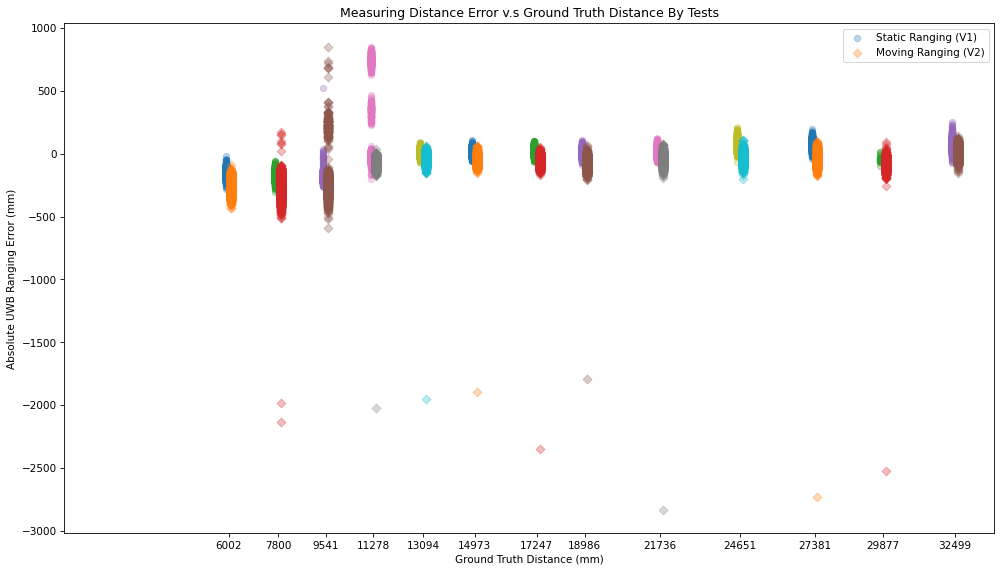

In [4]:
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax = figure.add_subplot(111)
ax.set_title("Measuring Distance Error v.s Ground Truth Distance By Tests")
labels = df_all_static_stats_dist_idx["Test Name"].astype(str)
ground_truths = []
i = 0
for test in list(labels.unique()):
    # Aggregated datapoints - all pairs of Master/Slaves
    # Static Vehicle (V1) as a receiver
    _test_df_static = df_all_static_stats_dist_idx[df_all_static_stats_dist_idx["Test Name"] == test]
    # Moving Vehicle (V2) as a receiver
    _test_df_moving = df_all_moving_stats_dist_idx[df_all_moving_stats_dist_idx["Test Name"] == test]
    if i > 0:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, alpha=0.3, marker="o")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, alpha=0.3, marker="D")
    else:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, alpha=0.3, marker="o", label="Static Ranging (V1)")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, alpha=0.3, marker="D", label="Moving Ranging (V2)")        
    # Collect the ground truth measurements    
    ground_truths.append(_test_df_moving.index.unique()[0])
    i += 1 
    
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xticks(ground_truths)
ax.set_xlim(left=0)
ax.set_ylabel("Absolute UWB Ranging Error (mm)")
ax.legend()
plt.show()

## Static Test Overall Stats, Error v.s. Distance, Main Master/Slave Pair Only

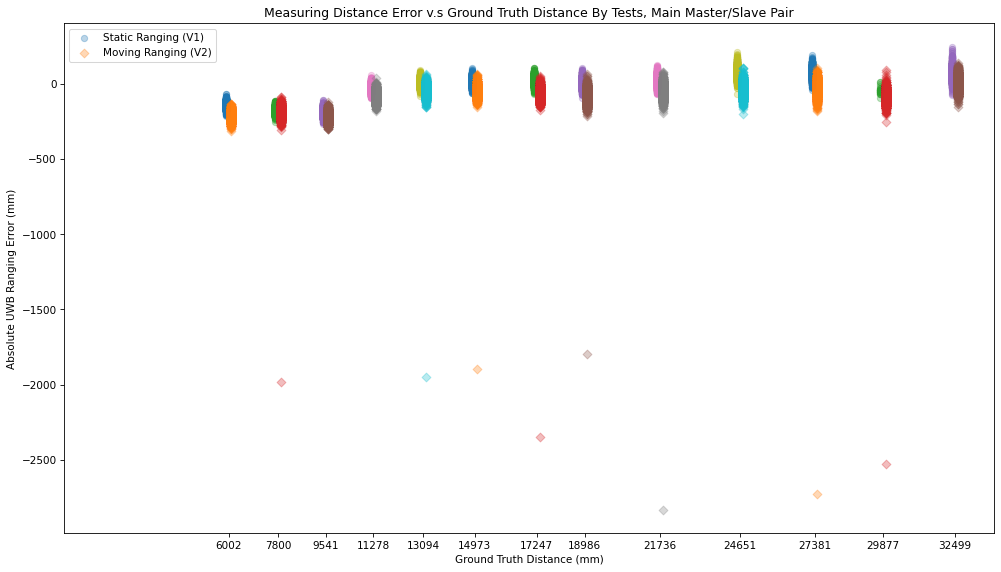

In [5]:
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax = figure.add_subplot(111)
ax.set_title("Measuring Distance Error v.s Ground Truth Distance By Tests, Main Master/Slave Pair")
labels = df_all_static_stats_dist_idx["Test Name"].astype(str)
ground_truths = []
i = 0
for test in list(labels.unique()):
    # Aggregated datapoints - the main pair of Master/Slaves
    # Static Vehicle (V1) as a receiver
    _test_df_static = df_all_static_stats_dist_idx[
        (df_all_static_stats_dist_idx["Test Name"] == test) \
        & (df_all_static_stats_dist_idx["Initiating Master"] == static_main_master) \
        & (df_all_static_stats_dist_idx["Reporting Slave"] == static_master_slave_mapping[static_main_master][0])]
    # Moving Vehicle (V2) as a receiver
    _test_df_moving = df_all_moving_stats_dist_idx[
        (df_all_moving_stats_dist_idx["Test Name"] == test) \
        & (df_all_moving_stats_dist_idx["Initiating Master"] == moving_main_master) \
        & (df_all_moving_stats_dist_idx["Reporting Slave"] == moving_master_slave_mapping[moving_main_master][0])]
    if i > 0:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, marker="o")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, marker="D")
    else:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, label="Static Ranging (V1)", marker="o")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, label="Moving Ranging (V2)", marker="D")
    ground_truths.append(_test_df_moving.index.unique()[0])
    i += 1
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xticks(ground_truths)
ax.set_xlim(left=0)
ax.set_ylabel("Absolute UWB Ranging Error (mm)")
ax.legend()
plt.show()

## Static Test Overall Stats, Connection Establishment Time  v.s. Distance

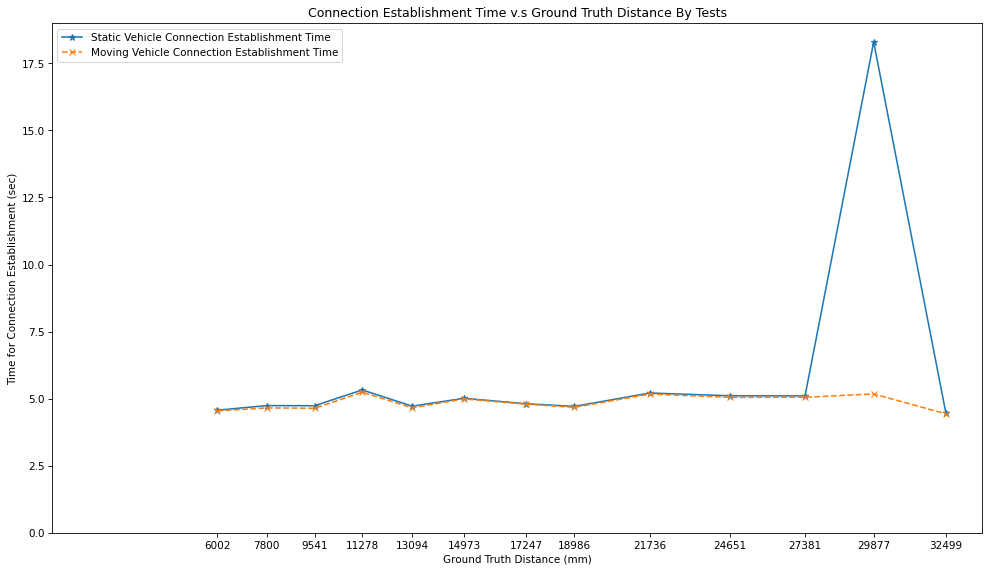

In [6]:
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax = figure.add_subplot(111)
ax.set_title("Connection Establishment Time v.s Ground Truth Distance By Tests")
labels = df_all_static_stats_aggregated["Test Name"].astype(str)
_x, _y = [], []
__x, __y = [], []
for test in list(labels.unique()):
    _test_df = df_all_static_stats_aggregated[df_all_static_stats_aggregated["Test Name"] == test]
    _est_time_sec = abs(_test_df['First Report Time'] - _test_df['Test Start Time'])
    _x.append(_test_df["Static Ground Truth (mm)"].unique()[0])
    _y.append(_est_time_sec.dt.total_seconds().unique()[0])
    
for test in list(labels.unique()):
    _test_df = df_all_moving_stats_aggregated[df_all_moving_stats_aggregated["Test Name"] == test]
    _est_time_sec = abs(_test_df['First Report Time'] - _test_df['Test Start Time'])
    __x.append(_test_df["Static Ground Truth (mm)"].unique()[0])
    __y.append(_est_time_sec.dt.total_seconds().unique()[0])
    
ax.plot(_x, _y, label="Static Vehicle Connection Establishment Time", marker="*")
ax.plot(__x, __y, label="Moving Vehicle Connection Establishment Time", marker="x", linestyle="--")
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xticks(ground_truths)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_ylabel("Time for Connection Establishment (sec)")
ax.legend()
plt.show()

## Static Tests, Overall Statistics among All Tests (Aggregated)

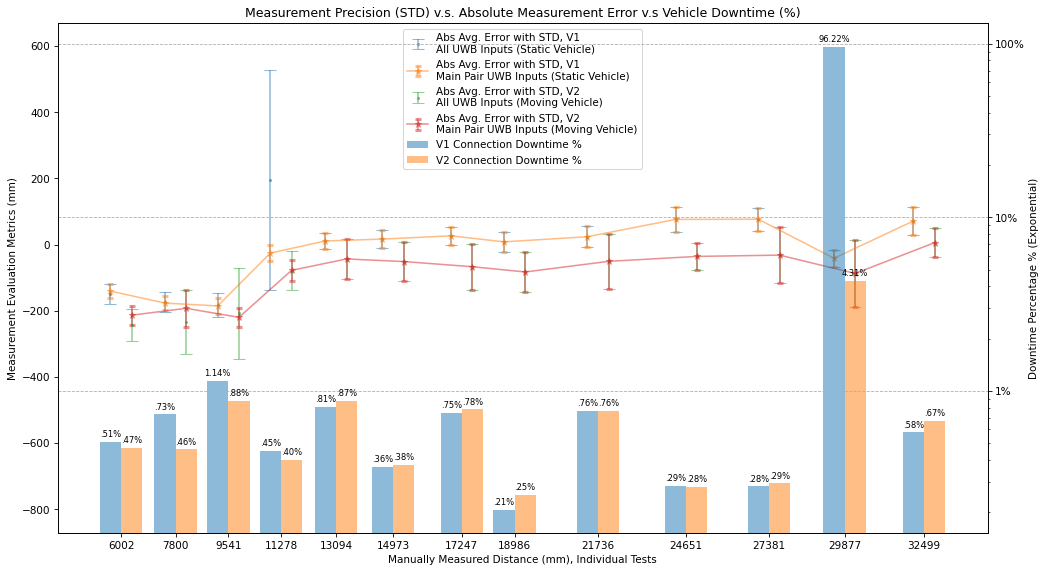

In [7]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
width = 700
labels = df_all_static_stats_aggregated["Static Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Absolute Measurement Error v.s Vehicle Downtime (%)")
df_main_pair_static_veh_stats_static_test = df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & (df_all_static_stats_pairwise["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_static_test = df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & (df_all_moving_stats_pairwise["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=df_all_static_stats_aggregated["Static Ground Truth (mm)"]-width/2, 
                       y=df_all_static_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_1_1 = ax.errorbar(x=df_main_pair_static_veh_stats_static_test["Static Ground Truth (mm)"]-width/2, 
                         y=df_main_pair_static_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_2 = ax.errorbar(x=df_all_moving_stats_aggregated["Static Ground Truth (mm)"]+width/2, 
                       y=df_all_moving_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
errbar_2_1 = ax.errorbar(x=df_main_pair_moving_veh_stats_static_test["Static Ground Truth (mm)"]+width/2, 
                         y=df_main_pair_moving_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated["Static Ground Truth (mm)"])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
_ylim, _ylim_range = ax.get_ylim(), max(ax.get_ylim()) - min(ax.get_ylim())
_new_y_lim = (_ylim[0] - _ylim_range * 0.5, _ylim[1] + _ylim_range * 0.1)
ax.set_ylim(_new_y_lim)
ax2 = ax.twinx()

rects1 = ax2.bar(df_all_static_stats_aggregated["Static Ground Truth (mm)"]-width/2,
                 df_all_static_stats_aggregated["Downtime Duration"] / df_all_static_stats_aggregated["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(STATIC_VEH), alpha=0.5)
rects2 = ax2.bar(df_all_static_stats_aggregated["Static Ground Truth (mm)"]+width/2, 
                 df_all_moving_stats_aggregated["Downtime Duration"] / df_all_moving_stats_aggregated["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(MOVING_VEH), alpha=0.5)

ax2.set_ylabel("Downtime Percentage % (Exponential)")
ax2.set_yscale('log')
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects1, rects2], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), rects1.get_label(), rects2.get_label()], 
          loc='upper center')
plt.show()


## Static Tests, Overall Statistics among All UWB Devices

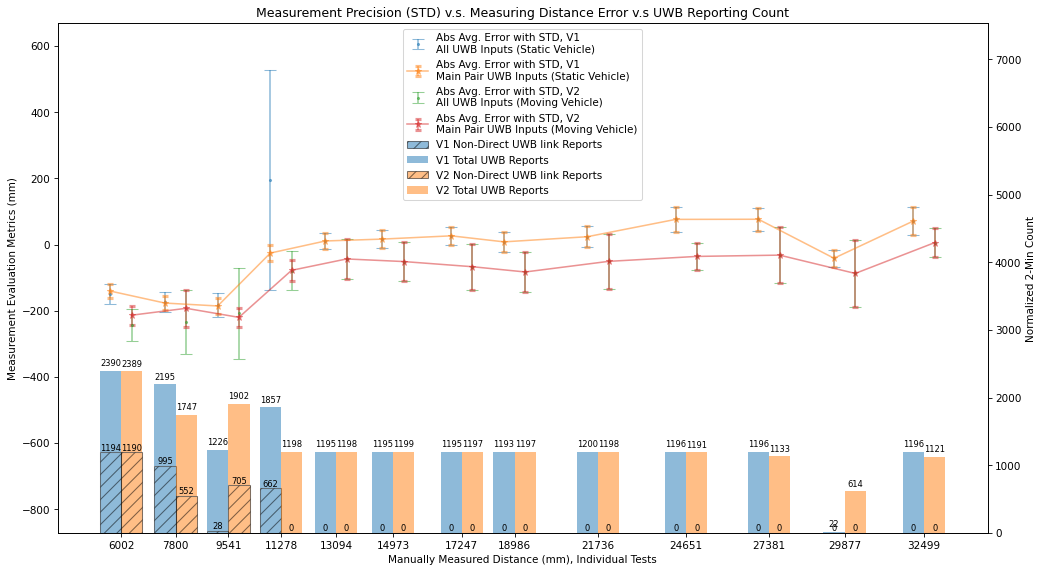

In [8]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
width = 700
labels = df_all_static_stats_aggregated["Static Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s UWB Reporting Count")
df_main_pair_STATIC_VEH_stats_static_test = df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & (df_all_static_stats_pairwise["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_static_test = df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & (df_all_moving_stats_pairwise["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=df_all_static_stats_aggregated["Static Ground Truth (mm)"]-width/2, 
                       y=df_all_static_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_1_1 = ax.errorbar(x=df_main_pair_STATIC_VEH_stats_static_test["Static Ground Truth (mm)"]-width/2, 
                         y=df_main_pair_STATIC_VEH_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_STATIC_VEH_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_2 = ax.errorbar(x=df_all_moving_stats_aggregated["Static Ground Truth (mm)"]+width/2, 
                       y=df_all_moving_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
errbar_2_1 = ax.errorbar(x=df_main_pair_moving_veh_stats_static_test["Static Ground Truth (mm)"]+width/2, 
                         y=df_main_pair_moving_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated["Static Ground Truth (mm)"])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
_ylim, _ylim_range = ax.get_ylim(), max(ax.get_ylim()) - min(ax.get_ylim())
_new_y_lim = (_ylim[0] - _ylim_range * 0.5, _ylim[1] + _ylim_range * 0.1)
ax.set_ylim(_new_y_lim)
ax2 = ax.twinx()

rects1 = ax2.bar(df_all_static_stats_aggregated["Static Ground Truth (mm)"]-width/2,
                (df_all_static_stats_aggregated["Main Pair Counts"]/df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"), 
                bottom=((df_all_static_stats_aggregated["Reporting Counts"] - df_all_static_stats_aggregated["Main Pair Counts"])/df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Total UWB Reports'.format(STATIC_VEH), alpha=0.5, color="C0")
rects0 = ax2.bar(df_all_static_stats_aggregated["Static Ground Truth (mm)"]-width/2,
                ((df_all_static_stats_aggregated["Reporting Counts"] - df_all_static_stats_aggregated["Main Pair Counts"])/df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Non-Direct UWB link Reports'.format(STATIC_VEH), alpha=0.5, color="C0", hatch="//", edgecolor='k')

rects3 = ax2.bar(df_all_static_stats_aggregated["Static Ground Truth (mm)"]+width/2, 
                (df_all_moving_stats_aggregated["Main Pair Counts"]/df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"), 
                bottom=((df_all_moving_stats_aggregated["Reporting Counts"] - df_all_moving_stats_aggregated["Main Pair Counts"])/df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Total UWB Reports'.format(MOVING_VEH), alpha=0.5, color="C1")
rects2 = ax2.bar(df_all_static_stats_aggregated["Static Ground Truth (mm)"]+width/2, 
                ((df_all_moving_stats_aggregated["Reporting Counts"] - df_all_moving_stats_aggregated["Main Pair Counts"])/df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Non-Direct UWB link Reports'.format(MOVING_VEH), alpha=0.5, color="C1", hatch="//", edgecolor='k')

ax2.set_ylabel("Normalized 2-Min Count")
ax2.bar_label(rects1, padding=3, fontsize=8)
ax2.bar_label(rects0, padding=0, fontsize=8)
ax2.bar_label(rects3, padding=3, fontsize=8)
ax2.bar_label(rects2, padding=0, fontsize=8)
_ylim, _ylim_range = ax2.get_ylim(), max(ax2.get_ylim()) - min(ax2.get_ylim())
_new_y_lim = (0, _ylim[1] + _ylim_range * 2)
ax2.set_ylim(_new_y_lim)
ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects0, rects1, rects2, rects3], 
          [errbar_1.get_label(),errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), rects0.get_label(), rects1.get_label(), rects2.get_label(), rects3.get_label()],
          loc='upper center')
plt.show()